# Approches semi-supervisées en traitement d'images

Réduisez la dimension des features (PCA, t-SNE) et appliquez un clustering (K-Means, DBSCAN) pour identifier des regroupements d’images similaires (avec le même nombre de groupes que votre dataset labellisé ici 2). Le but est de labelliser de façon non-supervisée les images pour lesquelles vous n’avez pas de label. On parle alors de labellisation “faible”.



## Importer les données

on importe les données précédemment calculées dans un dataframe.


In [1]:
import pandas as pd
import numpy as np
import os


# Load the dataframe with image list and features
# Adapte the data path with your configuration
data_path = "../data"
df_images_filepath = os.path.join(data_path, "images_features.parquet")
df_images = pd.read_parquet(df_images_filepath)

# Name of feature column
feature_column = [f"f_{i}" for i in range(2048)]

display(df_images)


,path,filename,format,width,height,mode,size_bytes,is_grayscale,brightness,contrast,...,f_2038,f_2039,f_2040,f_2041,f_2042,f_2043,f_2044,f_2045,f_2046,f_2047
0,data/avec_labels/cancer,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,jpg,512,512,RGB,20159,True,32,37,...,0.005332,0.002420,0.000000,0.040658,0.002660,0.295007,0.049811,0.130986,0.129422,0.000000
1,data/avec_labels/cancer,0f718241-8f63-4b55-81ce-315324b51069.jpg,jpg,512,512,RGB,18113,True,27,36,...,0.007254,0.000000,0.000000,0.001363,0.000000,0.000000,0.000000,0.131745,0.146682,0.001071
2,data/avec_labels/cancer,73352791-6331-48a0-b0d1-045fb31d376c.jpg,jpg,512,512,RGB,23490,True,40,44,...,0.000000,0.051002,0.000000,0.000000,0.000000,0.008049,0.016675,0.070556,0.025744,0.031750
3,data/avec_labels/cancer,d018fae6-42d9-4de3-acbf-6c2637c28482.jpg,jpg,512,512,RGB,23321,True,42,42,...,0.013008,0.013794,0.000000,0.000215,0.008916,0.063021,0.002253,0.128358,0.112788,0.000000
4,data/avec_labels/cancer,cb4e6fda-be13-454b-bbda-f75e184444d5.jpg,jpg,512,512,RGB,24468,True,53,41,...,0.002034,0.012773,0.000000,0.000000,0.009872,0.154682,0.018212,0.187469,0.011837,0.237796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,data/sans_label,71334459-58f0-4373-8805-6100e6d9b5ed.jpg,jpg,512,512,RGB,27831,True,104,91,...,0.000000,0.005378,0.000000,0.000000,0.000338,0.000000,0.497949,0.192432,0.019270,0.003347
1502,data/sans_label,b5a05df2-50ea-435b-8946-f4ba1bb1d9ac.jpg,jpg,512,512,RGB,26169,True,64,49,...,0.000000,0.000000,0.000000,0.000000,0.036624,0.005485,0.035494,0.070094,0.056662,0.027113
1503,data/sans_label,b5b311b5-9264-4d34-a9a5-8952ecf727cb.jpg,jpg,512,512,RGB,22737,True,32,38,...,0.001513,0.000000,0.004794,0.000000,0.000000,0.056435,0.063832,0.145722,0.047076,0.000000
1504,data/sans_label,40b1313e-6c50-488f-9066-bfefc7c5b2e1.jpg,jpg,512,512,RGB,14638,True,22,31,...,0.001831,0.162391,0.000000,0.000000,0.002723,0.000000,0.000000,0.000511,0.086267,0.000000


## Reduction de dimension



### Analyse en composantes principales

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Normalisation centré réduite
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_images[feature_column])

# Analyse en composante principale
pca = PCA()
pca = PCA(n_components=0.75) # ou 0.95 pour garder 95% variance


X_pca = pca.fit_transform(X_scaled)


display(X_pca.shape)
pca_column = [f"pca_{i}" for i in range(X_pca.shape[1])]

df_pca = pd.DataFrame(X_pca, columns=pca_column, index=df_images.index)
df_images_pca = pd.concat([df_images, df_pca], axis=1)


display(df_images_pca)


(1506, 271)

,path,filename,format,width,height,mode,size_bytes,is_grayscale,brightness,contrast,...,pca_261,pca_262,pca_263,pca_264,pca_265,pca_266,pca_267,pca_268,pca_269,pca_270
0,data/avec_labels/cancer,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,jpg,512,512,RGB,20159,True,32,37,...,-1.755996,0.042870,1.063025,0.068749,-0.597282,0.835054,1.743054,-1.073498,0.093902,3.106042
1,data/avec_labels/cancer,0f718241-8f63-4b55-81ce-315324b51069.jpg,jpg,512,512,RGB,18113,True,27,36,...,0.330383,0.975468,-1.346772,1.115604,0.805291,-1.156459,-0.174615,-0.498099,0.646638,0.856693
2,data/avec_labels/cancer,73352791-6331-48a0-b0d1-045fb31d376c.jpg,jpg,512,512,RGB,23490,True,40,44,...,0.067967,0.087033,1.461017,-0.423080,-0.334392,-1.928778,-1.192499,0.912153,0.212032,0.677105
3,data/avec_labels/cancer,d018fae6-42d9-4de3-acbf-6c2637c28482.jpg,jpg,512,512,RGB,23321,True,42,42,...,0.286547,1.984034,0.260232,0.885755,0.076713,0.701294,-2.455702,-2.328766,-0.610498,-2.703210
4,data/avec_labels/cancer,cb4e6fda-be13-454b-bbda-f75e184444d5.jpg,jpg,512,512,RGB,24468,True,53,41,...,-0.703438,-1.172789,0.971327,0.826614,-0.857492,0.482517,-1.366022,-0.382191,1.108046,-1.425450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,data/sans_label,71334459-58f0-4373-8805-6100e6d9b5ed.jpg,jpg,512,512,RGB,27831,True,104,91,...,-0.737333,-0.101618,0.761025,0.147798,1.567470,-1.384569,0.963515,-0.294328,1.849324,1.822841
1502,data/sans_label,b5a05df2-50ea-435b-8946-f4ba1bb1d9ac.jpg,jpg,512,512,RGB,26169,True,64,49,...,-0.091276,2.128909,0.882143,0.160571,-0.921865,-0.710058,0.560871,-0.497731,-0.013519,-0.461215
1503,data/sans_label,b5b311b5-9264-4d34-a9a5-8952ecf727cb.jpg,jpg,512,512,RGB,22737,True,32,38,...,1.343738,-0.324762,-1.355392,0.429114,-1.466064,2.653700,0.815427,0.113197,-1.228789,-0.202905
1504,data/sans_label,40b1313e-6c50-488f-9066-bfefc7c5b2e1.jpg,jpg,512,512,RGB,14638,True,22,31,...,0.896246,1.113818,-0.011736,-0.418342,0.320576,-0.686523,0.275887,-0.010273,0.272976,-0.504934


La courbe suivante, nous indique la perte d'information en fonction du nombre de dimensin que l'on souhaite garder pour les analyses suivantes.
Ici pour garder 75% de la variance nous avons 271 composantes.


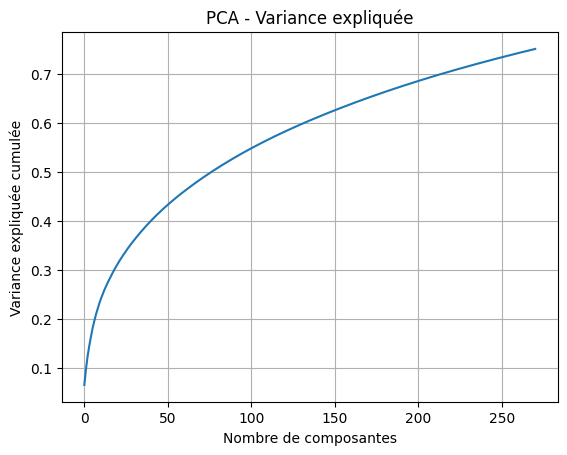

In [3]:
import matplotlib.pyplot as plt

import numpy as np

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

plt.plot(variance_cumulee)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("PCA - Variance expliquée")
plt.grid()
plt.show()



## Clustering

Ici nous visualisons les histogrammes des composantes afin de voir si il y a des clusthers qui apparaissent.
Lorsque il y a plusieurs sommets sur les histogrammes, c'est un signe de distribution sur plusieurs clusthers.
    
    

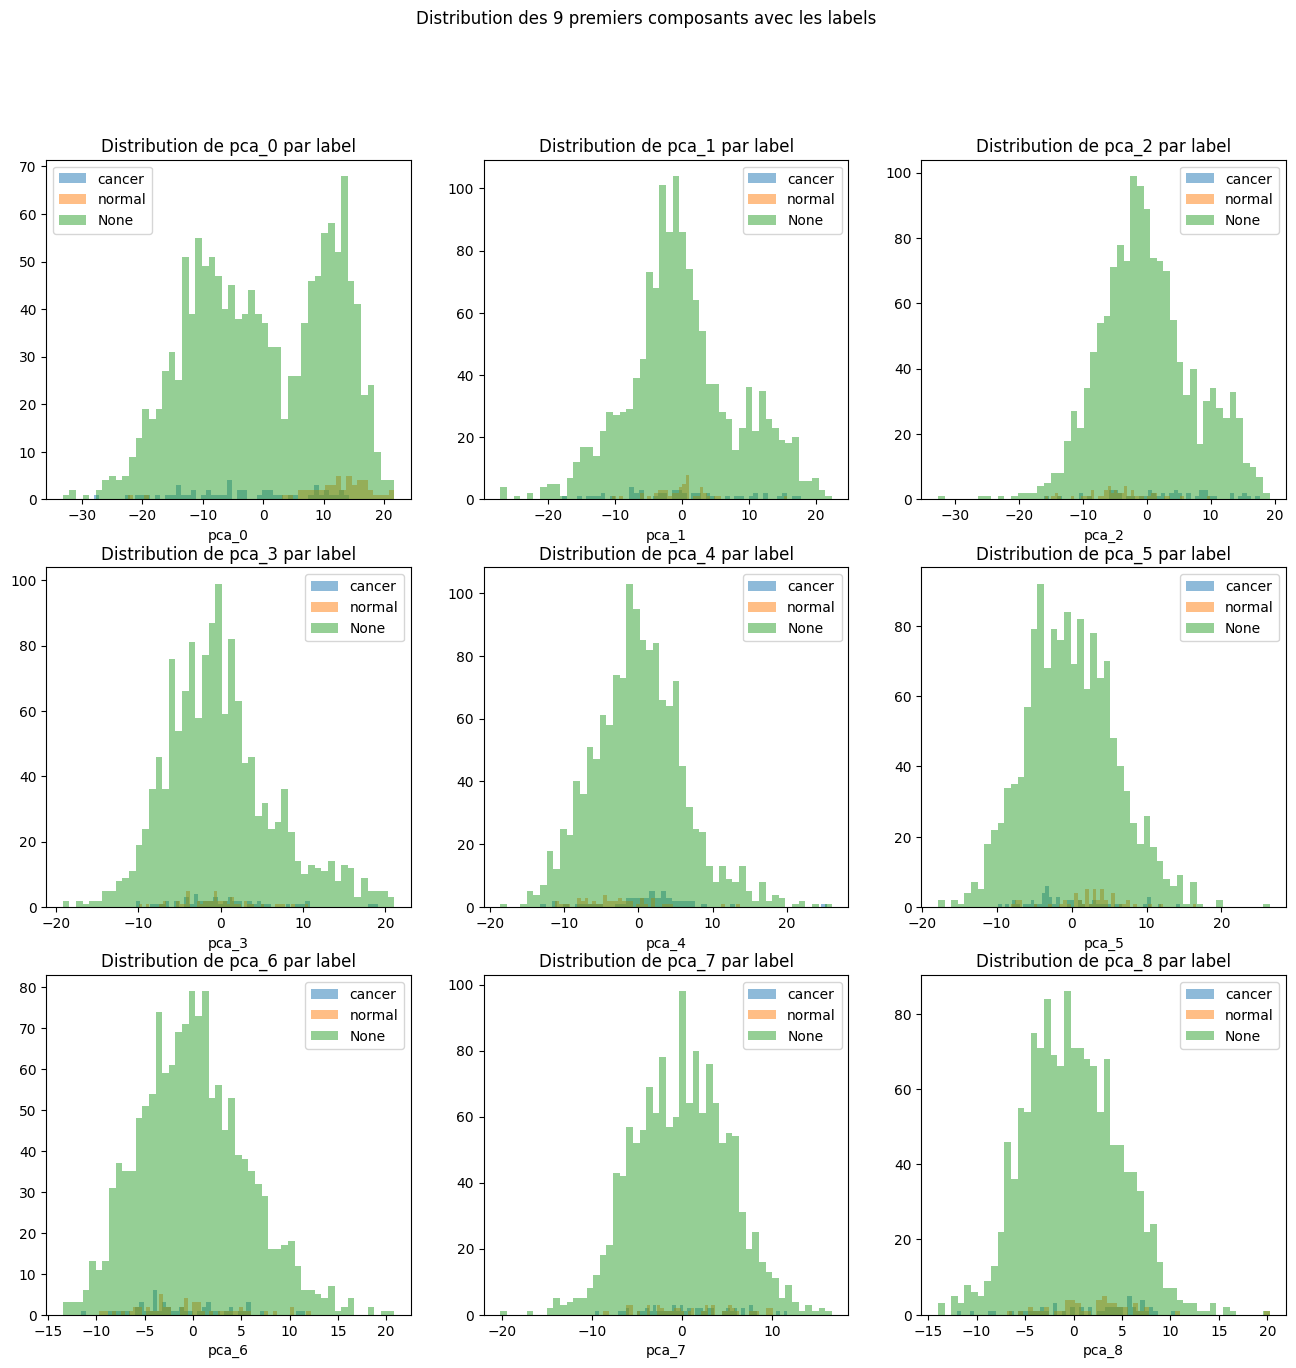

In [4]:
import matplotlib.pyplot as plt

states = df_images_pca["label"].unique()

axs_row = 0
axs_col = 0
axs_row_max = 3
axs_col_max = 3
fig, axs = plt.subplots(axs_row_max, axs_col_max, figsize=(16, 5 * axs_row_max))
fig.suptitle('Distribution des 9 premiers composants avec les labels')
    
for i in range(axs_row_max * axs_col_max):
    
    for state in states:
        subset = df_images_pca[df_images_pca["label"] == state]
        axs[axs_row, axs_col].hist(subset[f"pca_{i}"], bins=50, alpha=0.5, label=state)

    axs[axs_row, axs_col].set_title(f"Distribution de pca_{i} par label")
    axs[axs_row, axs_col].set_xlabel(f"pca_{i}")
    #axs[axs_row, axs_col].ylabel("Fréquence")
    axs[axs_row, axs_col].legend()

    axs_col += 1
    if axs_col == axs_col_max:
        axs_col = 0
        axs_row += 1
    
plt.show()



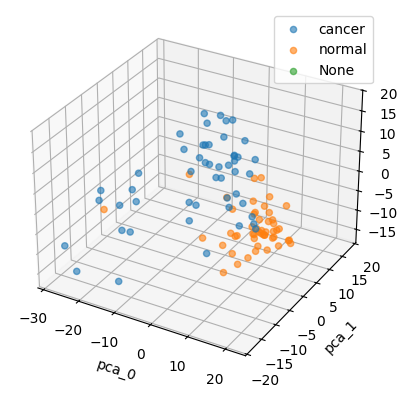

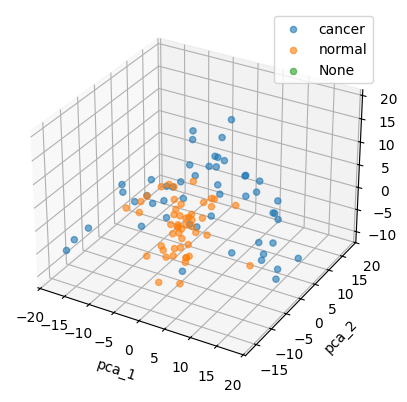

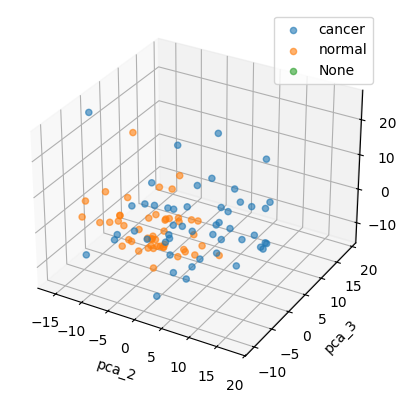

In [5]:

df_filtered = df_images_pca[df_images_pca["label"] != "None"]

for i in range(3):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for state in states:
        subset = df_filtered[df_filtered["label"] == state]
        
        ax.scatter(
            subset[f"pca_{i}"],
            subset[f"pca_{i+1}"],
            subset[f"pca_{i+2}"],
            label=state,
            alpha=0.6,
            s=20
        )
    
    ax.set_xlabel(f"pca_{i}")
    ax.set_ylabel(f"pca_{i+1}")
    ax.set_zlabel(f"pca_{i+2}")
    ax.legend()
    
    plt.show()

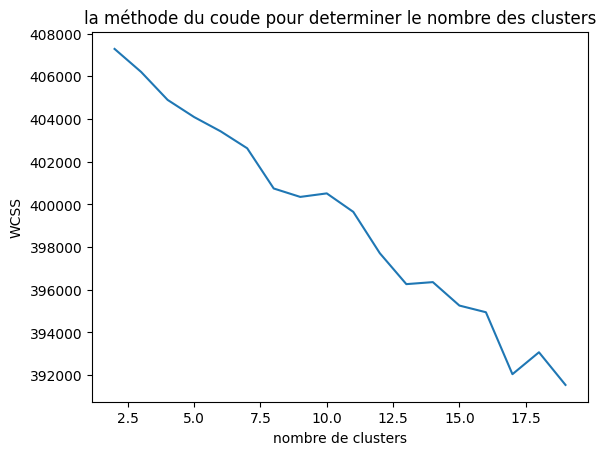

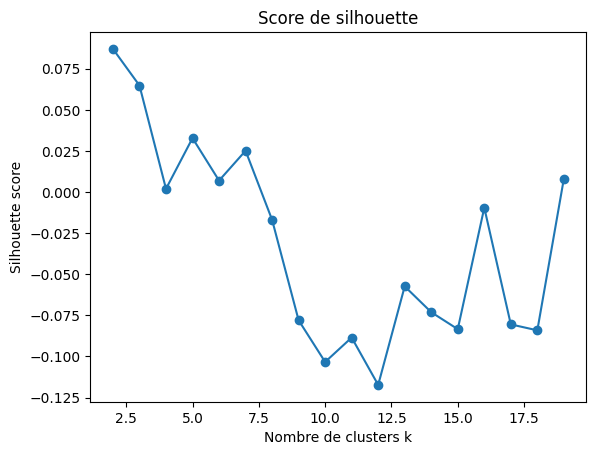

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_scaled2 = scaler.fit_transform(df_images_pca[pca_column].values)


n_clusters_max = 20
wcss = []
sil_scores = []

for i in range(2, n_clusters_max):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    labels = kmeans.fit_predict(X_scaled2)
    
    wcss.append(kmeans.inertia_)
    score = silhouette_score(X_scaled2, labels)
    sil_scores.append(score)

    #labels_kmeans = kmeans.fit_predict(X_pca)
    #score = silhouette_score(X_scaled, labels_kmeans)
    #print(i, score)
    

plt.plot(range(2, n_clusters_max), wcss)
plt.title('la méthode du coude pour determiner le nombre des clusters')
plt.xlabel('nombre de clusters')
plt.ylabel('WCSS')
plt.show()

plt.plot(range(2, n_clusters_max), sil_scores, marker='o')
plt.title("Score de silhouette")
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette score")
plt.show()


Pour la première courbe:
C’est la mesure de compacité du clustering.C’est la somme des distances au carré entre chaque point et le centroïde de son cluster.
On ne peut pas déduire de clusthering optimum sur cette lecture de courbe.


Pour la deuxieme courbe:
Pour chaque point, on mesure deux choses :

a = distance moyenne aux points de son cluster
b = distance moyenne aux points du cluster voisin le plus proche

Interprétation :

≈ 1 → très bien clusterisé
≈ 0 → à la frontière
< 0 → mal classé

Ici on peut voir des clustering les mieux séparés pour 5 clusthers. Au dela de 8 le clustering n'est pas éfficace.

Les métriques ne semblent pas indiquer un bon score de clustering d'une façon générale.



In [7]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', n_init=2000)
kmeans_labels = kmeans.fit_predict(X_scaled2)

df_images_pca["cluster"] = kmeans_labels

ct = pd.crosstab(df_images_pca["label"], df_images_pca["cluster"])
print(ct)

cluster     0  1    2    3  4
label                        
None     1158  3  120  124  1
cancer     41  0    6    3  0
normal     44  0    1    5  0


Bien que visuelllement on voit des clusters sur les vues 3D, il ne semble pas le Kmeans soit adapté à notre cas pour isoler des clusters pertinents pour notre cas.


In [8]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=30.0, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)


df_images_pca["cluster_dbscan"] = labels_dbscan
ct = pd.crosstab(df_images_pca["label"], df_images_pca["cluster_dbscan"])
print(ct)

cluster_dbscan    -1   0   1   2   3   4   5
label                                       
None            1344  18   6   4   6  23   5
cancer            48   0   0   0   0   2   0
normal            37   6   1   3   1   1   1
